In [ ]:
import sys
from pathlib import Path

ROOT = Path().resolve().parents[0]
sys.path.append(str(ROOT))

In [2]:
from config import SEED, N_LIST, METHODS, RESULTS_PATH
from models.cvae import train_cvae_on_arrays, sample_cvae_dataset
from models.bootstrap import sample_bootstrap
from models.gmm import sample_gmm
import numpy as np
import pandas as pd
from metrics import *
import ipywidgets as widgets
from IPython.display import display


# Loading Data
1. Breast cancer
2. Pima Indians Diabetes
3. Somethng else 3

#### 1. Breast Cancer

| Dataset | Category | n | p | Class 0 | Class 1 | Source | Notes |
|---------|----------|---|---|--------|--------|--------|-------|
| Breast Cancer | clinical_tabular | 569 | 30 | 212 | 357 | sklearn | moderate n, moderate p, numeric only |

#### 2. Diabetes

| Dataset | Category | n | p | Class 0 | Class 1 | Source | Notes |
|---------|----------|---|---|--------|--------|--------|-------|
| Diabetes| metabolic_tabular | 768 | 8 | 500 | 268 | openml | high n, low p, numeric only |

In [3]:
from loaders import load_breast, load_diabetes
data = load_diabetes()

X = data["X"]
y = data["y"]
feature_names = data["feature_names"]

print(data["dataset"], data["category"])
print(X.shape, y.shape)
print(np.bincount(y))

diabetes metabolic_tabular
(768, 8) (768,)
[500 268]


# Helper Functions
- Stratify Sampler

In [4]:
X_small, y_small, idx_small = stratified_subsample(X, y, n0=23, n1=68, seed=42)
print(X_small.shape)
print(np.bincount(y_small))

(91, 8)
[23 68]


- Train & sample CVAE

In [5]:

best_state = train_cvae_on_arrays(
    X,
    y,
    seed=42,
    z_dim=16,
    hidden=128,
    beta=0.5,
    lr=1e-3,
    epochs=200,
    batch_size=32,
)

X_syn, y_syn = sample_cvae_dataset(
    best_state,
    n0=23,
    n1=68,
    seed=42
)

print(X_syn.shape)
print(np.bincount(y_syn))

Epoch  50 | val loss=4.7374 recon=2.5630 kl=4.3488
Epoch 100 | val loss=4.4148 recon=2.2144 kl=4.4007
Epoch 150 | val loss=4.4392 recon=2.2550 kl=4.3685
Epoch 200 | val loss=4.5792 recon=2.4522 kl=4.2541
(91, 8)
[23 68]


- bootstrap

In [6]:
X_syn_b, y_syn_b = sample_bootstrap(X_small, y_small, n0=23, n1=68, seed=42)

- gmm

In [7]:
X_syn_g, y_syn_g = sample_gmm(X_small, y_small, n0=23, n1=68, seed=42, n_components=2)

## Selection Side
- `forward` means keep top k
- `reverse` means drop top k

In [8]:
def select_feature_subset(X, feature_names, mode="full", ranked_idx=None, k=None, drop_idx=None):
    p = X.shape[1]
    
    if mode == "full":
        keep = np.arange(p)

    elif mode == "drop_one":
        keep = np.array([j for j in range(p) if j != drop_idx])

    elif mode == "forward":
        keep = np.array(ranked_idx[:k])

    elif mode == "reverse":
        keep = np.array(ranked_idx[k:])

    else:
        raise ValueError(f"Unknown mode: {mode}")

    return keep

In [9]:
def rank_features_by_rf_importance(X, y, seed=42, n_estimators=15):
    rf = RandomForestClassifier(n_estimators=n_estimators, random_state=seed)
    rf.fit(X, y)
    return np.argsort(rf.feature_importances_)[::-1]

## Displaying Plots

In [10]:
def show_figures(figures, dataset=None, method=None, plot =None):
    for item in figures:
        if dataset is not None and item["dataset"] != dataset:
            continue
        if method is not None and item["method"] != method:
            continue

        fig_obj = item["fig"]

        if isinstance(fig_obj, dict):
            if plot is None:
                selected = fig_obj.items()
            else:
                if plot not in fig_obj:
                    continue
                selected = [(plot, fig_obj[plot])]

            for name, fig in selected:
                print(f"{item['dataset']} | {item['method']} | {name}")
                display(fig)
        else:
            print(f"{item['dataset']} | {item['method']}")
            display(fig_obj)

# The actual tests with numbers or something

RF trial 1/200
RF trial 10/200
RF trial 20/200
RF trial 30/200
RF trial 40/200
RF trial 50/200
RF trial 60/200
RF trial 70/200
RF trial 80/200
RF trial 90/200
RF trial 100/200
RF trial 110/200
RF trial 120/200
RF trial 130/200
RF trial 140/200
RF trial 150/200
RF trial 160/200
RF trial 170/200
RF trial 180/200
RF trial 190/200
RF trial 200/200
{'rf_auc_mean': np.float64(0.8234444444444443), 'rf_auc_sd': np.float64(0.07435243069743776), 'rf_sep_mean': np.float64(0.8234444444444443), 'rf_sep_sd': np.float64(0.07435243069743776), 'corr_mean_abs_diff': np.float64(0.08930229582894858), 'corr_max_abs_diff': np.float64(0.3061933104872404), 'pval_mean': np.float64(0.09139023476274132), 'pval_median': np.float64(0.008072108845435947), 'prop_significant': np.float64(0.75)}


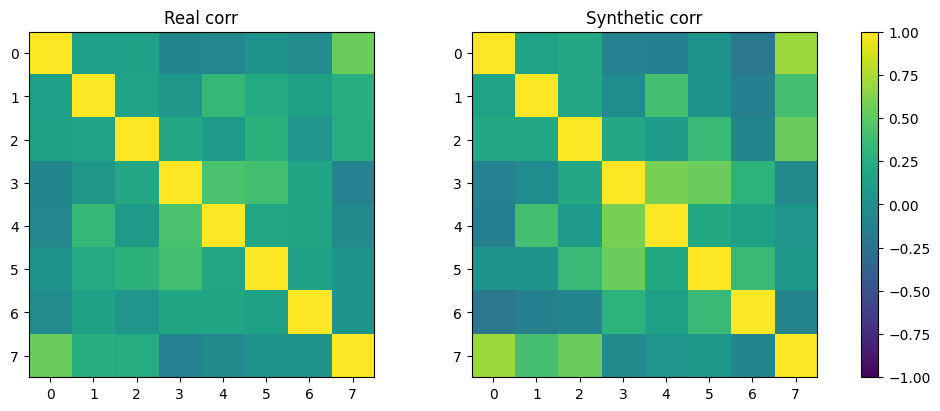

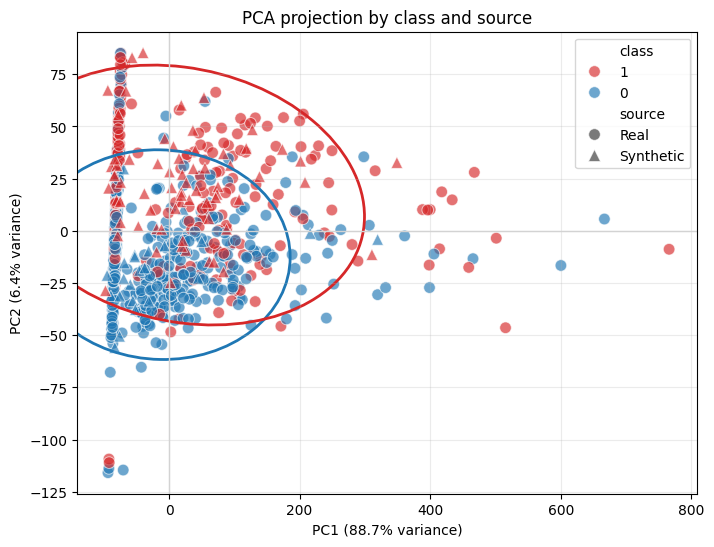

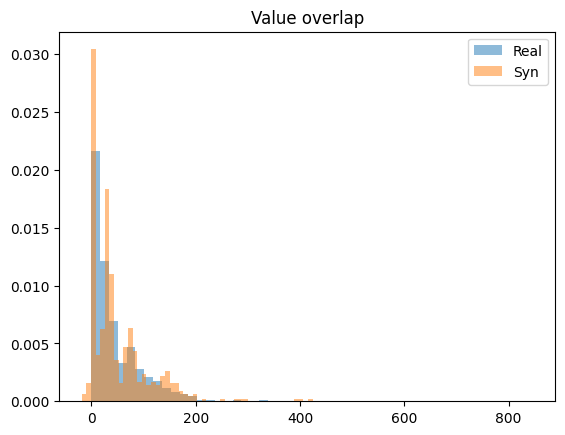

In [36]:
metrics, figures = evaluate_all(X_real=X, X_syn=X_syn, y_real= y, y_syn = y_syn)
print(metrics)


### Results row

In [ ]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

def run_experiment(n0, n1, feature_mode = "full", k = None, drop_idx = None, rows=[], figs = None):
    datasets = [
        load_breast,
        # load_diabetes,
    ]

    methods = ["bootstrap", "gmm", "cvae"]
    

    for load_fn in datasets:
        data = load_fn()
        X = data["X"]
        y = data["y"]
        feature_names = data["feature_names"]
        X_small, y_small, _ = stratified_subsample(
            X, y,
            n0=n0,
            n1=n1,
            seed=42
        )
        ranked_idx = rank_features_by_rf_importance(X_small, y_small, seed=42)
        keep = select_feature_subset(
            X_small,
            feature_names,
            mode=feature_mode,
            ranked_idx=ranked_idx,
            k=k,
            drop_idx=drop_idx
        )

        X_use = X_small[:, keep]
        feature_names_use = [feature_names[j] for j in keep]



## SAMPLING
        for method in methods:
            if method == "bootstrap":
                X_syn, y_syn = sample_bootstrap(X_use, y_small, n0, n1, seed=42)

            elif method == "gmm":
                X_syn, y_syn = sample_gmm(X_use, y_small, n0, n1, seed=42)

            elif method == "cvae":
                print("Training CVAE for", data["dataset"])
                best = train_cvae_on_arrays(
                    X_use,
                    y_small,
                    seed=42,
                    epochs=50,   
                    batch_size=32,

                )
                X_syn, y_syn = sample_cvae_dataset(best, n0, n1, seed=42)


        ## EVAL
            print(f"Evaluating {data['dataset']} | {method}")
            metrics, fig = evaluate_all(X_real=X_use, y_real= y_small,  X_syn=X_syn, y_syn = y_syn)

            if feature_mode == "full":
                n_features_used_label = f"{X_use.shape[1]}"
            elif feature_mode == "drop_one":
                n_features_used_label = f"{X_use.shape[1]}"
            elif feature_mode == "forward":
                n_features_used_label = f"top {k}"
            elif feature_mode == "reverse":
                n_features_used_label = f"drop top {k}"
            else:
                n_features_used_label = "unknown"

            row = {
                "dataset": data["dataset"],
                "category": data["category"],
                "n0": n0,
                "n1": n1,
                "method": method,
                "feature_mode": feature_mode,
                "k": None,
                "drop_idx": None,
                "n_features_used": n_features_used_label,
                "n_features_total": X.shape[1],
                "rf_auc_mean": metrics["rf_auc_mean"],
                "rf_auc_sd": metrics["rf_auc_sd"],
                "corr_mean_abs_diff": metrics["corr_mean_abs_diff"],
                "prop_significant": metrics["prop_significant"],
                # f1 scores
            }

            if feature_mode in {"forward", "reverse"}:
                row["k"] = k
            elif feature_mode == "drop_one":
                row["drop_idx"] = drop_idx

            rows.append(row)

            if figs is not None:
                figs.append({
                    "dataset": data["dataset"],
                    "method": method,
                    "fig": fig,
                })

            if isinstance(fig, dict):
                for f in fig.values():
                    plt.close(f)
            else:
                plt.close(fig)
    # df = pd.DataFrame(rows)
    # display(df)

### TEMP TESTING

In [13]:
rows = []
figures = []
run_experiment(n0=60, n1= 60,  feature_mode = "full", rows = rows, figs = figures)
df = pd.DataFrame(rows)
display(df)
print(len(figures))
print(figures[0].keys())

Evaluating breast_cancer | bootstrap
RF trial 1/200
RF trial 10/200
RF trial 20/200
RF trial 30/200
RF trial 40/200
RF trial 50/200
RF trial 60/200
RF trial 70/200
RF trial 80/200
RF trial 90/200
RF trial 100/200
RF trial 110/200
RF trial 120/200
RF trial 130/200
RF trial 140/200
RF trial 150/200
RF trial 160/200
RF trial 170/200
RF trial 180/200
RF trial 190/200
RF trial 200/200
Evaluating breast_cancer | gmm
RF trial 1/200
RF trial 10/200
RF trial 20/200
RF trial 30/200
RF trial 40/200
RF trial 50/200
RF trial 60/200
RF trial 70/200
RF trial 80/200
RF trial 90/200
RF trial 100/200
RF trial 110/200
RF trial 120/200
RF trial 130/200
RF trial 140/200
RF trial 150/200
RF trial 160/200
RF trial 170/200
RF trial 180/200
RF trial 190/200
RF trial 200/200
Training CVAE for breast_cancer
Epoch  50 | val loss=13.9689 recon=9.9760 kl=7.9860
Evaluating breast_cancer | cvae
RF trial 1/200
RF trial 10/200
RF trial 20/200
RF trial 30/200
RF trial 40/200
RF trial 50/200
RF trial 60/200
RF trial 70/2

,dataset,category,n0,n1,method,feature_mode,k,drop_idx,n_features_used,n_features_total,rf_auc_mean,rf_auc_sd,corr_mean_abs_diff,prop_significant
0,breast_cancer,clinical_tabular,60,60,bootstrap,full,None,None,30,30,0.344089,0.089416,0.061283,0.000000
1,breast_cancer,clinical_tabular,60,60,gmm,full,None,None,30,30,0.543011,0.099345,0.051594,0.000000
2,breast_cancer,clinical_tabular,60,60,cvae,full,None,None,30,30,0.866722,0.061724,0.099148,0.033333


3
dict_keys(['dataset', 'method', 'fig'])


In [18]:
df.to_csv("../results/synthetic_results_all.csv", index=False)

In [21]:
df

,dataset,category,n0,n1,method,feature_mode,k,drop_idx,n_features_used,n_features_total,rf_auc_mean,rf_auc_sd,corr_mean_abs_diff,prop_significant
0,breast_cancer,clinical_tabular,60,60,bootstrap,full,None,None,30,30,0.344089,0.089416,0.061283,0.000000
1,breast_cancer,clinical_tabular,60,60,gmm,full,None,None,30,30,0.543011,0.099345,0.051594,0.000000
2,breast_cancer,clinical_tabular,60,60,cvae,full,None,None,30,30,0.866722,0.061724,0.099148,0.033333


In [24]:
evaluate_abl(df)

{}

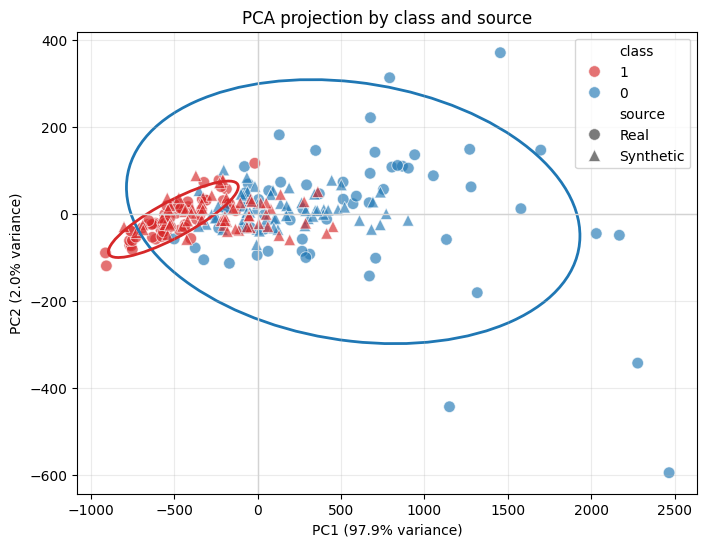

In [27]:
# CVAE
figures[2]['fig']['pca']

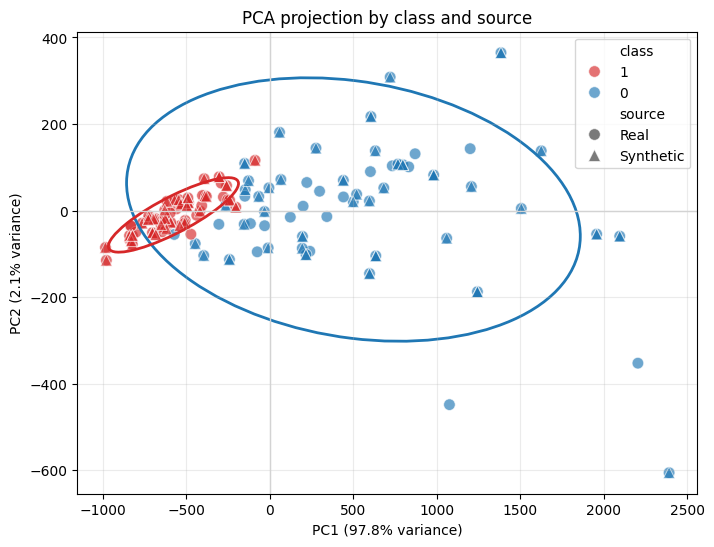

In [26]:
#bootstrap
figures[0]['fig']['pca']

breast_cancer | bootstrap | pca


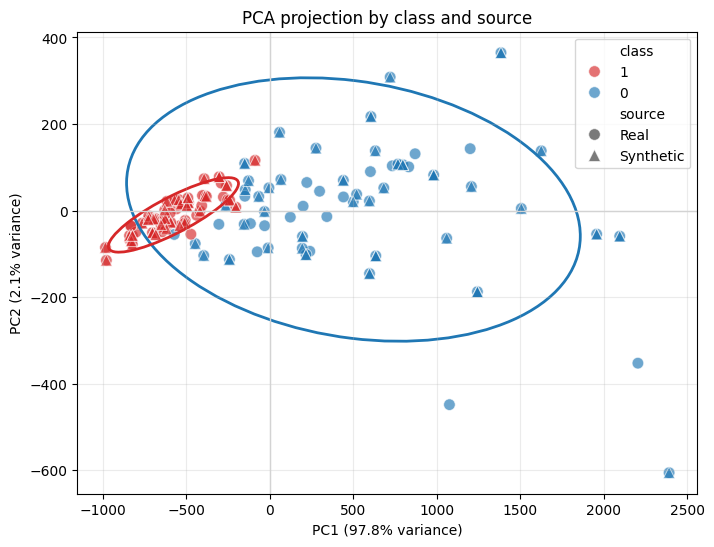

In [15]:
show_figures(figures, dataset="breast_cancer", method="bootstrap", plot="pca")

# Full Data Run
does synthetic quality depend on sample size?

In [16]:
rows = []

for n0, n1 in [(23,68),(35,35),(50,50),(60,60)]:
    run_experiment(
        n0,
        n1,
        feature_mode="full",
        rows=rows
    )

df = pd.DataFrame(rows)
display(df)

Evaluating breast_cancer | bootstrap
RF trial 1/200
RF trial 10/200
RF trial 20/200
RF trial 30/200
RF trial 40/200
RF trial 50/200
RF trial 60/200


KeyboardInterrupt: 

# Drop One Test
Does one feature control the realism?

In [ ]:
rows = []

for j in range(30):
    run_experiment(60,60,feature_mode="drop_one",drop_idx=j, rows = rows)

df = pd.DataFrame(rows)
display(df)

# Ablation

In [ ]:
all_rows = []

for k in [3, 5, 10, 15, 20]:
    run_experiment(
        n0=60,
        n1=60,
        feature_mode="forward",
        k=k,
        rows=all_rows
    )

for k in [1, 3, 5, 10]:
    run_experiment(
        n0=60,
        n1=60,
        feature_mode="reverse",
        k=k,
        rows=all_rows
    )

df_all = pd.DataFrame(all_rows)
display(df_all)

In [ ]:
summary_figs = evaluate_abl(df_all)

# Okay, evereything is tested. Please work.

In [ ]:
all_rows = []
figures = []
# FULL 
for n0, n1 in [(23,68),(35,35),(50,50),(60,60)]:
    print(f"full: ({n0, n1})")
    run_experiment(
        n0,
        n1,
        feature_mode="full",
        rows=all_rows,
        figs = figures
    )


# DROP ONE 
for j in range(30):
    run_experiment(
        60,
        60,
        feature_mode="drop_one",
        drop_idx=j,
        rows=all_rows,
        figs = figures
    )


# FORWARD
for k in [3, 5, 10, 15, 20]:
    print(f"forward: {k}")
    run_experiment(
        n0=60,
        n1=60,
        feature_mode="forward",
        k=k,
        rows=all_rows,
        figs = figures
    )


# REVERSE
for k in [1, 3, 5, 10]:
    print(f"reverse: {k}")
    run_experiment(
        n0=60,
        n1=60,
        feature_mode="reverse",
        k=k,
        rows=all_rows,
        figs = figures
    )


df_all = pd.DataFrame(all_rows)

print(df_all.shape)
display(df_all.head())

Evaluating breast_cancer | bootstrap
RF trial 1/200
RF trial 10/200
RF trial 20/200
RF trial 30/200
RF trial 40/200
RF trial 50/200
RF trial 60/200
RF trial 70/200
RF trial 80/200
RF trial 90/200
RF trial 100/200
RF trial 110/200
RF trial 120/200
RF trial 130/200
RF trial 140/200
RF trial 150/200
RF trial 160/200
RF trial 170/200
RF trial 180/200
RF trial 190/200
RF trial 200/200
Evaluating breast_cancer | gmm
RF trial 1/200
RF trial 10/200
RF trial 20/200
RF trial 30/200
RF trial 40/200
RF trial 50/200
RF trial 60/200
RF trial 70/200
RF trial 80/200
RF trial 90/200
RF trial 100/200
RF trial 110/200
RF trial 120/200
RF trial 130/200
RF trial 140/200
RF trial 150/200
RF trial 160/200
RF trial 170/200
RF trial 180/200
RF trial 190/200
RF trial 200/200
Training CVAE for breast_cancer
Epoch  50 | val loss=8.8147 recon=7.0463 kl=3.5368
Epoch 100 | val loss=7.2705 recon=5.1225 kl=4.2959
Epoch 150 | val loss=7.4674 recon=5.3607 kl=4.2135
Epoch 200 | val loss=7.1162 recon=4.9244 kl=4.3834
Eval

In [ ]:
df_all.to_csv("results/synthetic_results_all.csv", index=False)

In [41]:
all_rows = []
figures = []
print(f"full: ({n0, n1})")
run_experiment(
    n0 = 60,
    n1= 60,
    feature_mode="full",
    rows=all_rows,
    figs = figures
)


full: ((23, 68))
Evaluating breast_cancer | bootstrap
RF trial 1/200
RF trial 10/200
RF trial 20/200
RF trial 30/200
RF trial 40/200
RF trial 50/200
RF trial 60/200
RF trial 70/200
RF trial 80/200
RF trial 90/200
RF trial 100/200
RF trial 110/200
RF trial 120/200
RF trial 130/200
RF trial 140/200
RF trial 150/200
RF trial 160/200
RF trial 170/200
RF trial 180/200
RF trial 190/200
RF trial 200/200
Evaluating breast_cancer | gmm
RF trial 1/200
RF trial 10/200
RF trial 20/200
RF trial 30/200
RF trial 40/200
RF trial 50/200
RF trial 60/200
RF trial 70/200
RF trial 80/200
RF trial 90/200
RF trial 100/200
RF trial 110/200
RF trial 120/200
RF trial 130/200
RF trial 140/200
RF trial 150/200
RF trial 160/200
RF trial 170/200
RF trial 180/200
RF trial 190/200
RF trial 200/200
Training CVAE for breast_cancer
Epoch  50 | val loss=15.6093 recon=12.1786 kl=6.8612
Evaluating breast_cancer | cvae
RF trial 1/200
RF trial 10/200
RF trial 20/200
RF trial 30/200
RF trial 40/200
RF trial 50/200
RF trial 60

In [47]:
df_all = pd.DataFrame(all_rows)

temp = evaluate_abl(df_all)

temp

{}